In [79]:
## Import
from data import Data
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller


In [80]:
## Load data
data = Data()

Loading data...
Data already exists
Data loaded succesfully!


In [81]:
## Get the train data.
prod_id_list = data.get_prod_id_list()
NUM_DATA = 1000

d1 = pd.DataFrame({"Id": prod_id_list.iloc[0:NUM_DATA],
                    "Day_wise Sales": [data.get_train_data(prod, choice1='train', choice2='single_prod_day_wise') for prod in tqdm(prod_id_list.iloc[0:NUM_DATA])]                   
                    })
d1

100%|██████████| 1000/1000 [03:13<00:00,  5.17it/s] 


,Id,Day_wise Sales
0,HOBBIES_1_001_CA_1_validation,d_896 d_897 d_898 d_899 d_900 d_901 d...
1,HOBBIES_1_002_CA_1_validation,d_140 d_141 d_142 d_143 d_144 d_145 d...
2,HOBBIES_1_003_CA_1_validation,d_1099 d_1100 d_1101 d_1102 d_1103 d_1...
3,HOBBIES_1_004_CA_1_validation,d_35 d_36 d_37 d_38 d_39 d_40 d_41 d...
4,HOBBIES_1_005_CA_1_validation,d_112 d_113 d_114 d_115 d_116 d_117 d...
...,...,...
995,HOUSEHOLD_1_440_CA_1_validation,state_id d_1 d_2 d_3 d_4 d_5 d_6 d_...
996,HOUSEHOLD_1_441_CA_1_validation,d_1673 d_1674 d_1675 d_1676 d_1677 d...
997,HOUSEHOLD_1_442_CA_1_validation,d_1134 d_1135 d_1136 d_1137 d_1138 d...
998,HOUSEHOLD_1_443_CA_1_validation,d_21 d_22 d_23 d_24 d_25 d_26 d_27 ...


In [82]:
## Analyze AutoCorrelation

def get_acf_lag():
    pass

In [83]:
## Analyze Partial AutoCorrelation

def get_pacf_lag():
    pass

In [93]:
d1['Day_wise Sales'].iloc[7]

,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,...,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800
7,CA,12,15,0,0,0,4,6,5,7,...,9,0,17,0,7,2,9,7,7,30


In [95]:
# list(d1['Day_wise Sales'].iloc[i].values.tolist())[0][1:]

In [94]:
## Analyze affects of differencing
null_hypothesis_prob__list = []
THRESHOLD = 0.05
for i in range(d1.shape[0]):
    result = adfuller(list(d1['Day_wise Sales'].iloc[i].values.tolist())[0][1:])
    null_hypothesis_prob__list.append(result[1])

# null_hypothesis_prob__list = pd.Series(null_hypothesis_prob__list)

num_non_staionary_data = (pd.Series(null_hypothesis_prob__list) > THRESHOLD).sum()
print(pd.Series(null_hypothesis_prob__list)[pd.Series(null_hypothesis_prob__list) > THRESHOLD])
print(num_non_staionary_data)
# def get_diff():
#   pass

2      0.136415
22     0.071105
29     0.076253
39     0.087326
47     0.107600
74     0.093416
84     0.050868
120    0.053715
153    0.784914
161    0.363519
172    0.059301
176    0.139086
177    0.070914
180    0.597467
192    0.190702
233    0.996949
243    0.096305
253    0.059232
271    0.415631
273    0.065940
330    0.148265
340    0.155095
345    0.898259
375    0.069981
576    0.059148
593    0.061028
595    0.319325
611    0.060934
623    0.091222
628    0.054272
655    0.091653
667    0.083215
679    0.103608
684    0.262360
704    0.070620
725    0.052595
774    0.087916
805    0.418087
812    0.060155
813    0.461967
826    0.078377
913    0.203986
954    0.083537
957    0.124051
964    0.171311
965    0.189570
985    0.093005
996    0.276229
dtype: float64
48


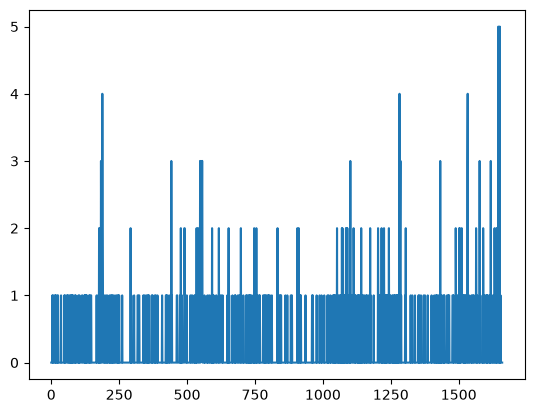

In [ ]:
plt.plot(list(d1['Day_wise Sales'].iloc[1].values.tolist())[0])